# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Tangaran, Grisby Paul James
- _Student No._: 2024-02777
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->
### Problem 1: Resistor Ladder

![Voltage Distribution Line Graph for 6 internal junctions](5-problem1-6.png)

Figure 1. Voltage Distribution Line Graph for 6 internal junctions

![Voltage Distribution Line Graphs for varied number of nodes](5-problem1-N.png)

Figure 2. Voltage Distribution on Linear and Semi-log scaled Graphs for varied number of nodes

The two graphs show how voltage drops across the resistor ladder network. 

The matrix equation $A\mathbf{v} = \mathbf{w}$ was constructed from basis linear equations derived from Kirchhoff's Current Law at each node (e.g., $3V_1 - V_2 - V_3 = V_+$). For Figure 1, this shows what happens when there are 6 junction points, solved using np.linalg.solve. In NumPy, np.linalg.solve(A, b) inherently uses LU decomposition under the hood via LAPACK routines (specifically _gesv) to solve the system $A\mathbf{x} = \mathbf{b}$. The voltage starts high near the power rail at the first two nodes (~3.8 V and ~3.6 V) and steadily decreases down toward 1 V by node 6, remaining strictly between the expected 0 V and 5 V range. 

Figure 2 compares network behavior across node counts from $N = 10$ to $N = 10,000$. To solve larger matrices more efficiently, Mark Newman's banded algorithm uses $\mathcal{O}(N)$ banded Gaussian elimination, bypassing the heavy memory overhead and $\mathcal{O}(N^3)$ complexity of standard solvers. Across all chain lengths, voltages remain strictly bounded between the $5\text{ V}$ input rail and $0\text{ V}$ at the final junction. Adding more resistors does not alter these voltage limits; instead, it reduces the node-by-node rate of potential decay. As a result, smaller networks display an abrupt voltage drop right at the start, whereas larger networks stretch the decay curve smoothly across all 10,000 nodes, clearly visualized across both linear and semi-log scales.

### Other comments
- None


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import banded as bd

In [16]:
V_plus = 5.0
N_1 = 6

#Matrix A and Vector w setup
A_1 = np.zeros((N_1, N_1))
w_1 = np.zeros(N_1)
w_1[0] = V_plus
w_1[1] = V_plus

for i in range(N_1):
    if i == 0 or i == N_1 - 1:
        A_1[i][i] = 3.0  # Set main diagonal value to 3.0 for first and last node
    else:
        A_1[i][i] = 4.0 # Set main diagonal value to 4.0 for internal nodes

    # Loop through relative off-diagonal neighbor offsets (-2, -1, +1, +2)
    for j in [i-2, i-1, i+1, i+2]:
        # Check that neighbor index sits within valid matrix boundaries
        if 0 <= j < N_1: 
            A_1[i, j] = -1 # Set off-diagonal coupling coefficient to -1.0

# 2. Solves the linear system
v_1 = np.linalg.solve(A_1, w_1)  

# 3. Print verification
print("A = \n", A_1)
print("\nw = ", w_1)
print("\nVoltages for N = 6 internal junctions:")
for i, voltage in enumerate(v_1):
    print(f" V_{i+1} = {voltage:.4f} V")

A = 
 [[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]

w =  [5. 5. 0. 0. 0. 0.]

Voltages for N = 6 internal junctions:
 V_1 = 3.7255 V
 V_2 = 3.4314 V
 V_3 = 2.7451 V
 V_4 = 2.2549 V
 V_5 = 1.5686 V
 V_6 = 1.2745 V


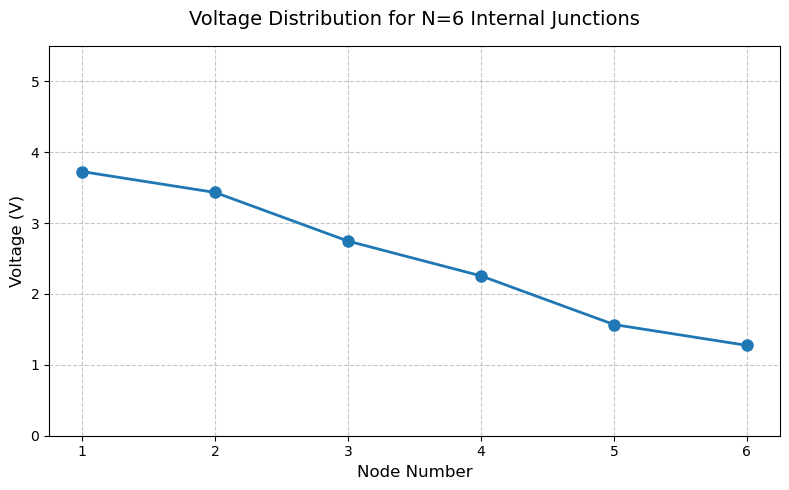

In [17]:
nodes = np.arange(1, N_1 + 1) # Generate 1 indexed node numbers array for x-axis plot display

plt.figure(figsize=(8, 5))
plt.plot(nodes, v_1, marker='o', linestyle='-', color='#1f77b4', markersize=8, linewidth=2)

# Formatting additions
plt.title("Voltage Distribution for N=6 Internal Junctions", fontsize=14, pad=15)
plt.xlabel("Node Number", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.xticks(nodes)       # Ensure only whole node numbers are ticked
plt.ylim(0, 5.5)        # Enforce bounds (0V to 5V) to check validity visually
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Lec5_TANGARAN_WX-1/5-problem1-6.png', bbox_inches='tight')
plt.show()

V1 = 4.998882277727716


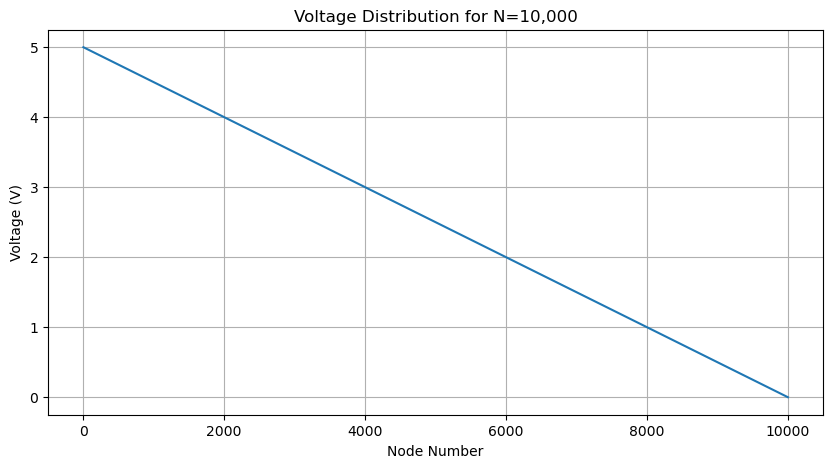

In [13]:
def resistor_ladder(N):
    """
    Constructs a 5xN banded matrix and solves the system Ax = w.
    
    Banded Matrix Indexing (up=2, down=2):
    Row 0: 2nd upper diagonal  (i-2)
    Row 1: 1st upper diagonal  (i-1)
    Row 2: Main diagonal       (i)
    Row 3: 1st lower diagonal  (i+1)
    Row 4: 2nd lower diagonal  (i+2)
    """
    A = np.zeros((5, N))

    # Main diagonal
    A[2, :] = 4
    A[2, 0] = 3
    A[2, N-1] = 3

    # Upper diagonals
    A[1, 1:] = -1
    A[0, 2:] = -1
    
    # Lower diagonals
    A[3, :-1] = -1
    A[4, :-2] = -1

    # Right-hand side vector
    w = np.zeros(N)
    w[0] = 5
    w[1] = 5

    # Solve and return (assuming bd.banded takes A, w, lower_bands, upper_bands)
    return bd.banded(A, w, 2, 2)


N_single = 10000
V_10k = resistor_ladder(N_single)
print(f"V1 = {V_10k[0]}")

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, N_single + 1), V_10k)
plt.xlabel("Node Number")
plt.ylabel("Voltage (V)")
plt.title(f"Voltage Distribution for N={N_single:,}")
plt.grid()
plt.savefig('5-problem1-10k.png', bbox_inches='tight')
plt.show()

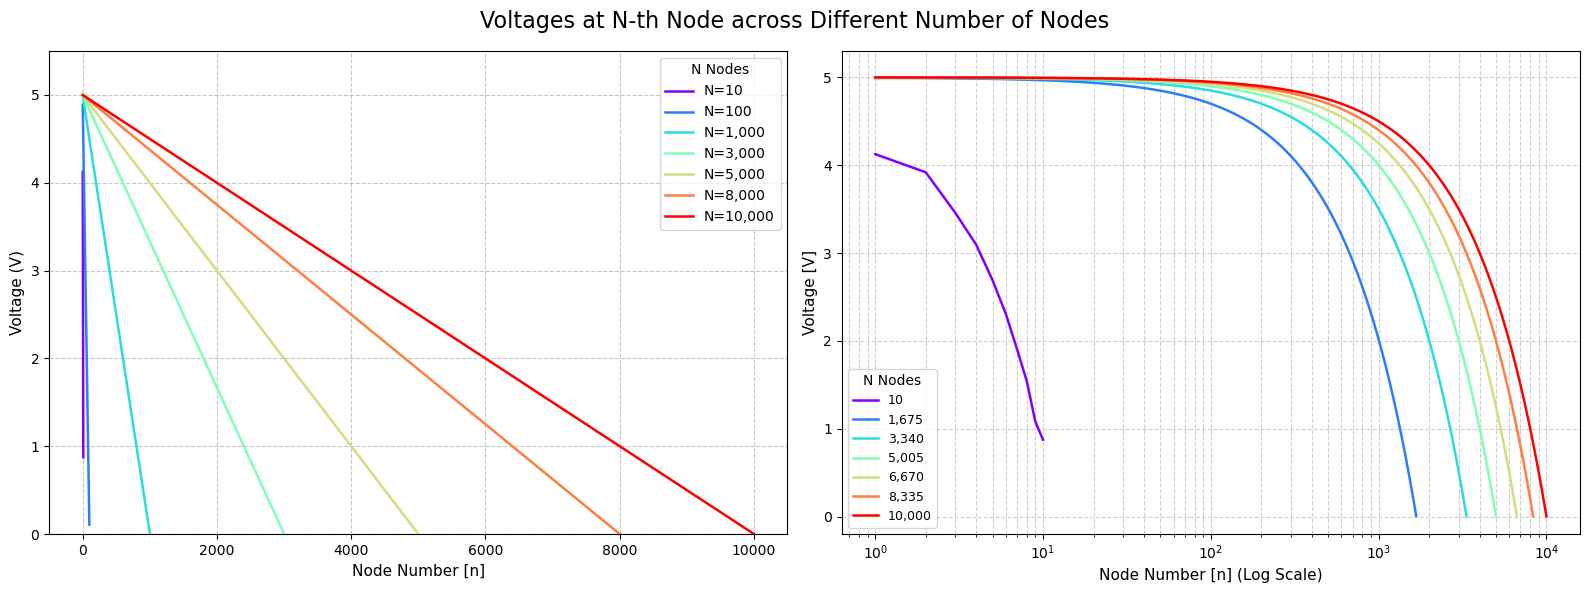

In [36]:
N_values = [10, 100, 1000, 3000, 5000, 8000, 10000]
# Compute voltage array for each N using dictionary comprehension
V_results = {N: resistor_ladder(N) for N in N_values}

# Create a single figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Voltages at N-th Node across Different Number of Nodes", fontsize=16)
#linear scale
colors1 = plt.cm.rainbow(np.linspace(0, 1, len(N_values)))

# Plot linear voltage decay curves across varying N
for idx, N in enumerate(N_values):
    ax1.plot(np.arange(1, N + 1), V_results[N], label=f"N={N:,}", color=colors1[idx], linewidth=1.8)

ax1.set_xlabel("Node Number [n]", fontsize=11)
ax1.set_ylabel("Voltage (V)", fontsize=11)
ax1.set_ylim(0, 5.5)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(title="N Nodes", fontsize=10)


# Plot on semi-logarithmic x-axis
node_counts = np.linspace(10, 10000, 7, endpoint=True, dtype=int)
colors2 = plt.cm.rainbow(np.linspace(0, 1, len(node_counts)))
for idx, N in enumerate(node_counts):
    v_sol = resistor_ladder(N)
    ax2.semilogx(np.arange(1, N + 1), v_sol, label=f"{N:,}", color=colors2[idx], linewidth=1.8)

ax2.set_xlabel("Node Number [n] (Log Scale)", fontsize=11)
ax2.set_ylabel("Voltage [V]", fontsize=11)
ax2.set_ylim(-0.2, 5.3)
ax2.grid(True, which="both", linestyle="--", alpha=0.6)
ax2.legend(title="N Nodes", loc="lower left", fontsize=9)

# Adjust spacing and save combined figure
plt.tight_layout()
plt.savefig('5-problem1-N.png', bbox_inches='tight')
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* This code applies Kirchhoff's Current Law at each resistor ladder junction to convert the circuit into a system of linear equations, which are solved using numpy's np.linalg.solve for N = 6 and Mark Newman's banded solver for N = 10000 because standard matrix solvers are too slow and memory-heavy. The code employs np.zeros and a compressed 5xN banded matrix to solve the circuit's pentadiagonal equations, and the results are then plotted using linear and semi-log scaled graphs across varying numbers of nodes to visualize the differences.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

In [22]:
A = np.array([[1,0,2],[-2,-1,3],[0,3,5]])
B = np.array([[-2],[1],[-3]])
print(A)
print(B)

[[ 1  0  2]
 [-2 -1  3]
 [ 0  3  5]]
[[-2]
 [ 1]
 [-3]]


In [24]:
ans = np.linalg.inv(A) @ B
print(ans)

[[-1.07692308]
 [-0.23076923]
 [-0.46153846]]


In [26]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.zeros((4,4))
x[1,2] = 5
for row in x:
    print(row)

#rint(x[0,1:3])


# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
#x_roll2 = np.roll(x, -1)
print(x_roll)

x_roll2 = np.roll(x, 2)
print(x_roll2)

[0. 0. 0. 0.]
[0. 0. 5. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[[0. 0. 0. 0.]
 [0. 0. 0. 5.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [5. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [28]:
# System of equations:
# 2x + y = 5
# x + 3y = 10
A = np.array([[2, 1], [1, 3]])
b = np.array([5, 10])

# Solve for x
x = np.linalg.solve(A, b)
print("Solution x:", x)

Solution x: [1. 3.]


In [29]:
import numpy as np
import scipy.linalg as la

A = np.array([[2, 1], [1, 3]])

# Computes P (permutation matrix), L (lower triangular), and U (upper triangular)
P, L, U = la.lu(A)
print("L:\n", L)
print("U:\n", U)

L:
 [[1.  0. ]
 [0.5 1. ]]
U:
 [[2.  1. ]
 [0.  2.5]]


In [30]:
import numpy as np

A = np.array([[2, 1], [1, 3]])

# Calculate inverse matrix A^-1[cite: 1]
A_inv = np.linalg.inv(A)
print("Inverse A^-1:\n", A_inv)

Inverse A^-1:
 [[ 0.6 -0.2]
 [-0.2  0.4]]


In [31]:
import numpy as np
import scipy.linalg as la

A = np.array([[2, 1], [1, 3]])

# Computes Q (orthogonal matrix) and R (upper triangular matrix)[cite: 1]
Q, R = la.qr(A)
print("Q:\n", Q)
print("R:\n", R)

Q:
 [[-0.89442719 -0.4472136 ]
 [-0.4472136   0.89442719]]
R:
 [[-2.23606798 -2.23606798]
 [ 0.          2.23606798]]


In [32]:
import numpy as np

A = np.array([[2, 1], [1, 3]])

# Returns eigenvalues (lambda) and normalized eigenvectors (x)[cite: 1]
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [1.38196601 3.61803399]
Eigenvectors:
 [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])